In [101]:
TICKER = "2330.TW"
TRAIN_START_DATE = "2020-01-01"
TRAIN_END_DATE = "2024-12-31"
TEST_START_DATE = "2025-01-01"
TEST_END_DATE = "2025-12-31"
INTERVAL = "1d"
FEATURES = [
    "Close",
    # "Volume",
    # "trend_sma_fast",
    # "trend_sma_slow",
    # "trend_macd",
    # "trend_macd_signal",
    # "trend_macd_diff",
    # "momentum_stoch",
    # "momentum_stoch_signal",
    # "momentum_rsi",
    # "volatility_bbm",
    # "volatility_bbh",
    # "volatility_bbl",
    # "volatility_bbw",
    # "volatility_bbp",
    # "trend_adx",
    # "trend_adx_pos",
    # "trend_adx_neg",
]
HOLDING_PENALTY_BASE = 0.0
WARMUP = 500
BATCH_SIZE = 128
EPS_DECAY = 0.98
EPISODES = 100
RISK_FREE_RATE = 0.0

In [102]:
from datetime import datetime, timedelta
import pandas as pd
import ta
import yfinance as yf


def download_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    train_start_date_new = datetime.strptime(TRAIN_START_DATE, "%Y-%m-%d")
    train_start_date_new -= timedelta(days=100)

    df = yf.download(
        TICKER,
        start=train_start_date_new.strftime("%Y-%m-%d"),
        end=TEST_END_DATE,
        interval=INTERVAL,
    )
    if df is None or df.empty:
        raise ValueError("Failed to download train data")

    df.columns = df.columns.droplevel(1)
    df = ta.add_all_ta_features(
        df, open="Open", high="High", low="Low", close="Close", volume="Volume"
    )

    def slice_data(start_date: str, end_date: str) -> pd.DataFrame:
        return df.loc[start_date:end_date, FEATURES]

    train = slice_data(TRAIN_START_DATE, TRAIN_END_DATE)
    test = slice_data(TEST_START_DATE, TEST_END_DATE)

    return train, test

In [103]:
import numpy as np
from numpy.typing import NDArray

class TradingEnv:
    """
    action:
        0 (hold)
        1 (open long)
        2 (open short)
        3 (close)
        4 (tighten stop)
    position: 0 (flat), 1 (long), -1 (short)
    reward: change in equity
    """

    def __init__(
        self,
        prices: NDArray[np.float32],
        window_size: int = 20,
        penalty_vol_scale: float = 20.0,
        init_cash: float = 100_000.0,
        fee_rate: float = 0.0005,
        slippage_rate: float = 0.0005,
        stop_atr_mult: float = 2.0,
    ) -> None:
        self.prices = prices
        self.window_size = window_size
        self.penalty_vol_scale = penalty_vol_scale
        self.init_cash = init_cash
        self.fee_rate = fee_rate
        self.slippage_rate = slippage_rate
        self.stop_atr_mult = stop_atr_mult

        self.state_size = window_size + 6
        self.action_size = 5

        self.reset()

    def reset(self) -> NDArray[np.float32]:
        self.t = self.window_size
        self.cash = self.init_cash
        self.equity = self.init_cash
        self.prev_equity = self.init_cash

        self.position = 0
        self.entry_price = 0.0
        self.position_size = 1
        self.holding_steps = 0
        self.stop_price = 0.0

        self.done = False

        return self._get_state()

    # ----- utility methods ----- #
    def _apply_cost(self, trade_notional: float) -> None:
        cost = trade_notional * (self.fee_rate + self.slippage_rate)
        self.cash -= cost

    def _calc_atr_like(self, t: int, lookback: int = 14) -> float:
        diffs = np.abs(np.diff(self.prices[t - lookback : t + 1]))
        return float(np.mean(diffs))

    def _check_stop_hit(self, price: float) -> bool:
        if self.position == 1 and price <= self.stop_price:
            return True
        elif self.position == -1 and price >= self.stop_price:
            return True
        return False

    def _mark_to_market(self, price: float) -> None:
        self.equity = self.cash + self._unrealized_pnl(price)

    def _penalty_multiplier(self, price: float) -> float:
        atr = self._calc_atr_like(self.t)
        vol_ratio = atr / price
        return 1.0 + (self.penalty_vol_scale * vol_ratio)

    def _unrealized_pnl(self, price: float) -> float:
        return (price - self.entry_price) * self.position * self.position_size

    # ----- action methods ----- #
    def _open_position(self, side: int, price: float) -> None:
        # side: 1 (long), -1 (short)
        self.position = side
        self.entry_price = price
        self.holding_steps = 0

        atr = self._calc_atr_like(self.t)
        if side == 1:
            self.stop_price = price - self.stop_atr_mult * atr
        else:
            self.stop_price = price + self.stop_atr_mult * atr

        self._apply_cost(price * self.position_size)

    def _close_position(self, price: float) -> None:
        pnl = (price - self.entry_price) * self.position * self.position_size
        self.cash += pnl
        self._apply_cost(price * self.position_size)

        self.position = 0
        self.entry_price = 0.0
        self.holding_steps = 0
        self.stop_price = 0.0

    def _tighten_stop(self, price: float) -> None:
        if self.position == 1:
            atr = self._calc_atr_like(self.t)
            new_stop = price - atr
            self.stop_price = max(self.stop_price, new_stop)
        elif self.position == -1:
            atr = self._calc_atr_like(self.t)
            new_stop = price + atr
            self.stop_price = min(self.stop_price, new_stop)

    # ----- core RL methods ----- #
    def _get_state(self) -> NDArray[np.float32]:
        window_prices = self.prices[self.t - self.window_size : self.t + 1]
        returns = np.diff(window_prices) / window_prices[:-1]  # return rate (20 states)

        price = self.prices[self.t]
        unrealized_pnl = self._unrealized_pnl(price)
        stop_dist = 0.0
        if self.position != 0:
            stop_dist = (price - self.stop_price) * self.position

        extra = np.array(
            [
                (self.equity - self.init_cash) / self.init_cash,  # equity change
                float(self.position),  # position
                self.holding_steps / 100.0,  # holding steps (normalized)
                unrealized_pnl / self.init_cash,  # unrealized PnL (normalized)
                stop_dist / price,  # stop distance (normalized)
                self._calc_atr_like(self.t) / price,  # ATR-like volatility
            ],
            dtype=np.float32,
        )

        state = np.concatenate([returns.astype(np.float32), extra])
        return state

    def get_valid_actions(self) -> list[int]:
        if self.position == 0:
            return [0, 1, 2]  # hold, open long, open short
        return [0, 3, 4]  # hold, close, tighten stop

    def step(self, action: int) -> tuple[float, NDArray[np.float32], bool, dict]:
        price = self.prices[self.t]
        penalty_mult = self._penalty_multiplier(price)
        holding_penalty = 0.0

        if action == 1:  # open long
            self._open_position(1, price)
        elif action == 2:  # open short
            self._open_position(-1, price)
        elif action == 3:  # close
            self._close_position(price)
        elif action == 4:  # tighten stop
            self._tighten_stop(price)

        # next step
        self.t += 1
        if self.t >= len(self.prices) - 1:
            self.done = True

        next_price = float(self.prices[self.t])

        if self.position != 0 and self._check_stop_hit(next_price):
            self._close_position(next_price)

        if self.position != 0:
            self.holding_steps += 1

        self.prev_equity = self.equity
        self._mark_to_market(next_price)

        reward = self.equity - self.prev_equity
        if (
            self.position != 0
        ):  # holding penalty scaled by volatility (prevent infinite holding)
            holding_penalty = penalty_mult * HOLDING_PENALTY_BASE
            reward -= holding_penalty

        next_state = self._get_state()
        info = {
            "holding_penalty": -holding_penalty,
        }
        return reward, next_state, self.done, info

In [104]:
import torch.nn as nn


class QNet(nn.Module):
    def __init__(self, state_dim: int, action_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x) -> nn.Sequential:
        return self.net(x)

In [105]:
from collections import deque
from dataclasses import dataclass
import random
from typing import Deque


@dataclass
class Transition:
    state: NDArray[np.float32]
    action: int
    reward: float
    next_state: NDArray[np.float32]
    done: bool


class ReplayBuffer:
    def __init__(self, capacity: int = 100_000) -> None:
        self.buffer: Deque[Transition] = deque(maxlen=capacity)

    def __len__(self) -> int:
        return len(self.buffer)

    def push(self, *args) -> None:
        self.buffer.append(Transition(*args))

    def sample(self, batch_size: int) -> tuple[
        NDArray[np.float32],
        NDArray[np.int64],
        NDArray[np.float32],
        NDArray[np.float32],
        NDArray[np.float32],
    ]:
        batch = random.sample(self.buffer, batch_size)

        state = np.array([b.state for b in batch], dtype=np.float32)
        action = np.array([b.action for b in batch], dtype=np.int64)
        reward = np.array([b.reward for b in batch], dtype=np.float32)
        next_state = np.array([b.next_state for b in batch], dtype=np.float32)
        done = np.array([b.done for b in batch], dtype=np.float32)

        return state, action, reward, next_state, done

In [106]:
import torch
import torch.optim as optim


def select_action(
    q: QNet, state: NDArray[np.float32], valid_actions: list[int], device: torch.device
) -> int:
    with torch.no_grad():
        q_values = q(
            torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        ).squeeze(0)

        mask = torch.full_like(q_values, -1e9)
        mask[valid_actions] = 0.0

        return int(torch.argmax(q_values + mask).item())


def train_model(
    prices: NDArray[np.float32], episodes: int = 20
) -> tuple[QNet, NDArray[np.float32]]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = TradingEnv(prices)
    q = QNet(env.state_size, env.action_size).to(device)
    q_target = QNet(env.state_size, env.action_size).to(device)
    q_target.load_state_dict(q.state_dict())

    optimizer = optim.Adam(q.parameters())
    rb = ReplayBuffer(capacity=50_000)

    gamma = 0.99
    warmup = WARMUP
    batch_size = BATCH_SIZE
    train_freq = 4
    target_update_freq = 500

    eps_start, eps_end, eps_decay = 1.0, 0.05, EPS_DECAY
    epsilon = eps_start

    global_step = 0

    ep_rewards = []
    for ep in range(1, episodes + 1):
        state = env.reset()
        ep_reward = 0.0
        ep_holding_penalty = 0.0

        while not env.done:
            global_step += 1

            valid_actions = env.get_valid_actions()
            if random.random() < epsilon:
                action = random.choice(valid_actions)
            else:
                action = select_action(q, state, valid_actions, device)

            reward, next_state, done, info = env.step(action)
            rb.push(state, action, reward, next_state, done)

            # ----- train ----- #
            if len(rb) > warmup and global_step % train_freq == 0:
                states, actions, rewards, next_states, dones = rb.sample(batch_size)

                states_t = torch.tensor(states, dtype=torch.float32, device=device)
                actions_t = torch.tensor(
                    actions, dtype=torch.long, device=device
                ).unsqueeze(1)
                rewards_t = torch.tensor(
                    rewards, dtype=torch.float32, device=device
                ).unsqueeze(1)
                next_states_t = torch.tensor(
                    next_states, dtype=torch.float32, device=device
                )
                dones_t = torch.tensor(
                    dones, dtype=torch.float32, device=device
                ).unsqueeze(1)

                q_values = q(states_t).gather(1, actions_t)

                with torch.no_grad():
                    position_idx = env.window_size + 1
                    next_position = next_states_t[:, position_idx]
                    is_flat = (
                        torch.abs(next_position) < 0.5
                    )  # prevent floating point issues

                    mask = torch.zeros(
                        (batch_size, env.action_size), dtype=torch.bool, device=device
                    )
                    mask[:, 0] = True
                    mask[is_flat, 1] = True
                    mask[is_flat, 2] = True
                    mask[~is_flat, 3] = True
                    mask[~is_flat, 4] = True

                    next_q_value_online = q(next_states_t).masked_fill(~mask, -1e9)
                    next_actions = torch.argmax(
                        next_q_value_online, dim=1, keepdim=True
                    )

                    next_q_value_target = q_target(next_states_t).masked_fill(
                        ~mask, -1e9
                    )
                    next_q_value = next_q_value_target.gather(1, next_actions)

                    target = rewards_t + gamma * (1.0 - dones_t) * next_q_value

                loss = nn.functional.smooth_l1_loss(q_values, target)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(q.parameters(), 5.0)
                optimizer.step()

            # ----- update target ----- #
            if global_step % target_update_freq == 0:
                q_target.load_state_dict(q.state_dict())

            # next step
            ep_reward += reward
            ep_holding_penalty += info["holding_penalty"]

            state = next_state

        print(
            f"[Episode {ep:03d}] Equity: {env.equity:9.2f} | Reward: {ep_reward:8.2f} (Holding: {ep_holding_penalty:6.2f}) | Epsilon: {epsilon:4.3f}"
        )

        ep_rewards.append(ep_reward)
        epsilon = max(eps_end, epsilon * eps_decay)

    return q, np.array(ep_rewards, dtype=np.float32)


def rewards_summary(rewards: NDArray[np.float32]) -> None:
    print("----- Reward Summary -----")
    print(f"Episodes:          {len(rewards)}")
    print(f"Avg:               {rewards.mean():.2f}")
    print(f"Std:               {rewards.std():.2f}")
    print(f"Min:               {rewards.min():.2f}")
    print(f"Max:               {rewards.max():.2f}")
    print(f"First 20 Avg:      {rewards[:20].mean():.2f}")
    print(f"Last 20 Avg:       {rewards[-20:].mean():.2f}")
    print(f"Positive Episodes: {(rewards > 0).mean() * 100:.2f}%\n")

In [107]:
import matplotlib.pyplot as plt


def test_model(q: QNet, prices: NDArray[np.float32]) -> tuple[
    NDArray[np.float32],
    NDArray[np.float32],
    NDArray[np.float32],
    list[dict],
    NDArray[np.float32],
]:
    device = next(q.parameters()).device

    env = TradingEnv(prices)
    state = env.reset()

    equities = [env.equity]
    returns = []
    rewards = []
    events = []
    trade_pnls = []

    entry_equity = env.equity
    prev_position = 0
    while not env.done:
        t = env.t

        valid_actions = env.get_valid_actions()
        action = select_action(q, state, valid_actions, device)

        reward, next_state, _, _ = env.step(action)

        equities.append(env.equity)
        returns.append((equities[-1] - equities[-2]) / equities[-2])
        rewards.append(reward)

        event = {"t": t, "price": env.prices[t]}
        if action == 1:
            events.append(event | {"type": "open_long"})
            entry_equity = env.equity
        elif action == 2:
            events.append(event | {"type": "open_short"})
            entry_equity = env.equity
        elif action == 3:
            events.append(event | {"type": "close"})
            trade_pnls.append(env.equity - entry_equity)
        elif action == 4:
            events.append(event | {"type": "tighten_stop"})
        if prev_position != 0 and env.position == 0 and action != 3:
            events.append({"t": env.t, "price": env.prices[env.t], "type": "stop_hit"})
            trade_pnls.append(env.equity - entry_equity)

        state = next_state
        prev_position = env.position

    return (
        np.array(equities),
        np.array(returns),
        np.array(rewards),
        events,
        np.array(trade_pnls),
    )


def max_drawdown(equity: NDArray[np.float32]) -> float:
    peak = np.maximum.accumulate(equity)
    drawdown = (equity - peak) / peak
    return drawdown.min()


def sharpe_ratio(
    returns: NDArray[np.float32], risk_free_rate: float, period_per_year: int = 252
) -> float:
    avg = returns.mean()
    std = returns.std()
    return np.sqrt(period_per_year) * (avg - risk_free_rate) / std


def plot_events(df: pd.DataFrame, events: list[dict]) -> None:
    df.reset_index(inplace=True)

    plt.figure(figsize=(24, 6))
    plt.plot(df.index, df["Close"], label="Close")

    style = {
        "open_long": ("^", "green"),
        "open_short": ("v", "red"),
        "close": ("o", "blue"),
        "tighten_stop": ("+", "orange"),
        "stop_hit": ("x", "black"),
    }
    for event in events:
        marker, color = style[event["type"]]
        plt.scatter(event["t"], event["price"], marker=marker, color=color, s=100)


def evaluate_results(
    equities: NDArray[np.float32],
    returns: NDArray[np.float32],
    rewards: NDArray[np.float32],
    events: list[dict],
    trade_pnls: NDArray[np.float32],
) -> None:
    total_return = (equities[-1] - equities[0]) / equities[0]
    win_rate = (trade_pnls > 0).mean()
    mdd = max_drawdown(equities)
    sr = sharpe_ratio(returns, RISK_FREE_RATE)

    print("----- Model Evaluation -----")
    print(f"Step Count:   {len(rewards)}")
    print(f"Trade Count:  {len(trade_pnls)}")
    print(f"Final Equity: {equities[-1]:.2f}")
    print(f"Total Return: {total_return * 100:.2f}%")
    print(f"Win Rate:     {win_rate * 100:.2f}%")
    print(f"Max Drawdown: {mdd * 100:.2f}%")
    print(f"Sharpe Ratio: {sr:.2f}")
    print(f"Reward Avg:   {rewards.mean():.2f}")
    print(f"Reward Std:   {rewards.std():.2f}")

[*********************100%***********************]  1 of 1 completed


[Episode 001] Equity:  99202.49 | Reward:  -797.51 (Holding:   0.00) | Epsilon: 1.000
[Episode 002] Equity:  99043.84 | Reward:  -956.16 (Holding:   0.00) | Epsilon: 0.980
[Episode 003] Equity: 100213.73 | Reward:   213.73 (Holding:   0.00) | Epsilon: 0.960
[Episode 004] Equity:  99852.69 | Reward:  -147.31 (Holding:   0.00) | Epsilon: 0.941
[Episode 005] Equity: 100131.52 | Reward:   131.52 (Holding:   0.00) | Epsilon: 0.922
[Episode 006] Equity:  99716.14 | Reward:  -283.86 (Holding:   0.00) | Epsilon: 0.904
[Episode 007] Equity:  99365.43 | Reward:  -634.57 (Holding:   0.00) | Epsilon: 0.886
[Episode 008] Equity:  99868.02 | Reward:  -131.98 (Holding:   0.00) | Epsilon: 0.868
[Episode 009] Equity:  99775.37 | Reward:  -224.63 (Holding:   0.00) | Epsilon: 0.851
[Episode 010] Equity:  99729.12 | Reward:  -270.88 (Holding:   0.00) | Epsilon: 0.834
[Episode 011] Equity:  99372.70 | Reward:  -627.30 (Holding:   0.00) | Epsilon: 0.817
[Episode 012] Equity: 100278.24 | Reward:   278.24 (Ho

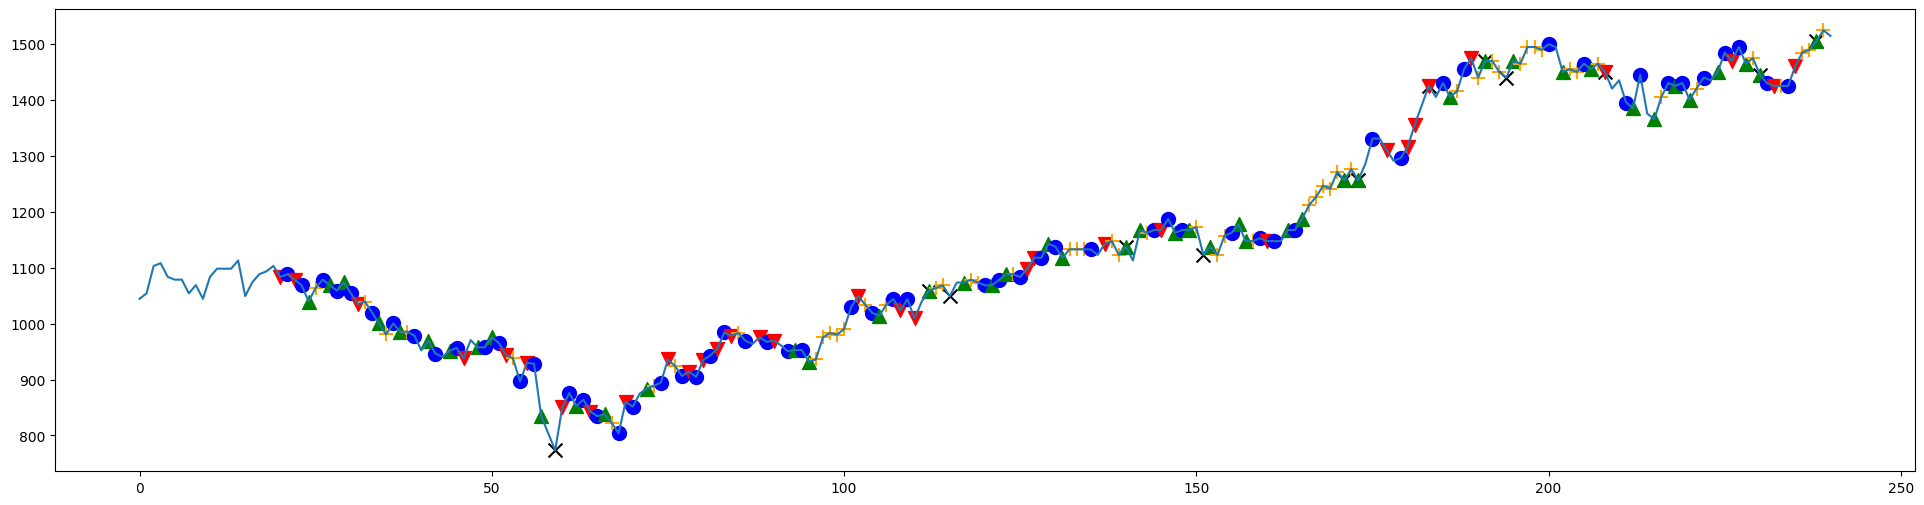

In [108]:
train, test = download_data()

model, rewards = train_model(train["Close"].to_numpy(dtype=np.float32), EPISODES)
rewards_summary(rewards)

equities, returns, rewards, events, trade_pnls = test_model(
    model, test["Close"].to_numpy(dtype=np.float32)
)
evaluate_results(equities, returns, rewards, events, trade_pnls)
plot_events(test, events)